In [1]:
import datetime
import torch
import torch.nn as nn
import libs
from libs.data_gene import *
from libs.config import * 
from libs.module import LatentModel, Decoder
from libs.train_module import trainer
from libs.evaluate_module import *


In [3]:

device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#sol_name = f"./data/solution_{config['eq_name']}.h5"

print(f"Using device : {device}")
print(f"Loading data : {config['sol_name']}")

# ── data ─────────────────────────────────────────────────
x_ref, train_loader, test_loader = get_dataloaders(
    config["sol_name"], batch_size=config["batch_size"]
)

for params_batch, phi_batch in train_loader:
    print("train params :", params_batch.shape)   # (B, 2)
    print("train phi    :", phi_batch.shape)       # (B, N)
    break

# ── models ───────────────────────────────────────────────
model1 = LatentModel(
    input_dim          = config["input_dim"],
    hidden_dims        = config["hidden_dims"],
    latent_feature_dim = config["latent_feature_dim"],
    n_latent           = config["n_latent"],
    activation         = config["activation"],
    output_activation  = config["output_activation"],
).to(device)

model2 = Decoder(
    latent_dim       = config["latent_feature_dim"],
    hidden_conv_dims = config["hidden_conv_dims"],
    output_sol_dim   = config["output_sol_dim"],
).to(device)

models = nn.ModuleList([model1, model2])

params_all, phi_pred, phi_true, rel_errors = evaluate_model(models, test_loader, device, config["model_save_path"], config["error_save_path"])


Using device : cpu
Loading data : ./data/solution_Ex1.h5
train params : torch.Size([32, 2])
train phi    : torch.Size([32, 4096])
Sequential(
  (0): ConvTranspose1d(16, 256, kernel_size=(4,), stride=(2,), padding=(1,))
  (1): ReLU()
  (2): ConvTranspose1d(256, 128, kernel_size=(4,), stride=(2,), padding=(1,))
  (3): ReLU()
  (4): ConvTranspose1d(128, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (5): ReLU()
  (6): ConvTranspose1d(64, 64, kernel_size=(4,), stride=(2,), padding=(1,))
  (7): ReLU()
  (8): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1,))
  (9): ReLU()
  (10): ConvTranspose1d(32, 32, kernel_size=(4,), stride=(2,), padding=(1,))
  (11): ReLU()
  (12): Conv1d(32, 1, kernel_size=(1,), stride=(1,))
)
The relative L2 error for each parameter is stored
Test MSE loss         : 0.000003
Mean relative L2 error: 0.0136 ± 0.0061


[0, 40, 80, 119]
Figure saved → ./result/Ex1_witherror_sampled_plot.png


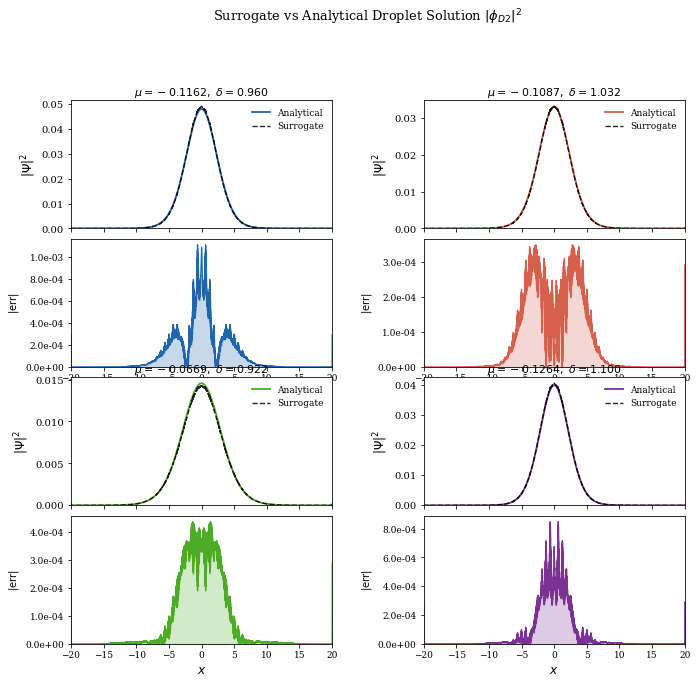

In [4]:

#params = np.concatenate([test_data['mu'][:, None], test_data['delta'][:, None]], axis = 1) 

plot_results_witherror(x_ref, params_all, phi_pred, phi_true,
            indices=None, save_path=config["save_path_witherror"]) 


 